In [1]:
import geopandas as gpd
from geodatasets import get_path
import shapely
from shapely import Polygon, Point
import ee
from matplotlib import pyplot as plt
import numpy as np

import rasterio
import pandas as pd
from rasterio.features import rasterize
from rasterio.transform import from_bounds

from shapely.geometry import Polygon, LineString
from shapely.ops import unary_union
from shapely import wkt
from rtree import index
from shapely import MultiLineString
import matplotlib

from pyproj import Transformer
from shapely.ops import transform




In [ ]:
gdf_2020 = gpd.GeoDataFrame.from_file(f"../../csvs/patches_hedgerows_merged_2020.csv", engine='pyogrio', use_arrow=True)
gdf_2020["geometry"] = gdf_2020["geometry"].apply(wkt.loads)
gdf_2020 = gpd.GeoDataFrame(gdf_2020, crs="4326")

gdf_2024 = gpd.GeoDataFrame.from_file(f"../../csvs/patches_hedgerows_merged_2024.csv", engine='pyogrio', use_arrow=True)
gdf_2024["geometry"] = gdf_2024["geometry"].apply(wkt.loads)
gdf_2024 = gpd.GeoDataFrame(gdf_2024, crs="4326")

gdf_2024['hedgerows'] = gdf_2024['hedgerows'].replace(['', ' ', 'None', 'null', 'NaN', None, np.nan], pd.NA)
gdf_2020['hedgerows'] = gdf_2020['hedgerows'].replace(['', ' ', 'None', 'null', 'NaN', None, np.nan], pd.NA)



In [ ]:
gdf_2024["hedgerows_2024"] = gdf_2024["hedgerows"].apply(
    lambda x: wkt.loads(x) if pd.notna(x) else None
)
gdf_2024["hedgerows_2020"] = gdf_2020["hedgerows"].apply(
    lambda x: wkt.loads(x) if pd.notna(x) else None
)

filtered_gdf = gdf_2024[gdf_2024['hedgerows_2024'].notna() | gdf_2024['hedgerows_2020'].notna()]
filtered_gdf

In [ ]:
filtered_gdf = filtered_gdf.drop(["hedgerows"],axis=1)
filtered_gdf

,field_1,field_1,geometry,hedgerows_2024,hedgerows_2020
872,872,872,"POLYGON ((-5.11665 48.45542, -5.10515 48.45542...",LINESTRING (-5.116647565200277 48.460143431194...,None
3322,3322,3322,"POLYGON ((-5.09365 48.45542, -5.08215 48.45542...",MULTILINESTRING ((-5.091588113664823 48.455592...,MULTILINESTRING ((-5.087781654415173 48.460865...
4547,4547,4547,"POLYGON ((-5.08215 48.45542, -5.07065 48.45542...",MULTILINESTRING ((-5.080937730652012 48.458186...,MULTILINESTRING ((-5.080747172179662 48.457216...
35159,35159,35159,"POLYGON ((-4.79469 48.35619, -4.78319 48.35619...",None,LINESTRING (-4.785683178240963 48.362467223218...
35160,35160,35160,"POLYGON ((-4.79469 48.36383, -4.78319 48.36383...",LINESTRING (-4.783250890699998 48.365695960042...,LINESTRING (-4.783348856521463 48.365679559741...
...,...,...,...,...,...
1561982,1561982,1561982,"POLYGON ((9.54386 42.28494, 9.55536 42.28494, ...",MULTILINESTRING ((9.545569357113168 42.2904447...,MULTILINESTRING ((9.543857871630312 42.2877315...
1561983,1561983,1561983,"POLYGON ((9.54386 42.29345, 9.55536 42.29345, ...",MULTILINESTRING ((9.544712404420144 42.3011536...,MULTILINESTRING ((9.545168124204048 42.3009596...
1561984,1561984,1561984,"POLYGON ((9.54386 42.30195, 9.55536 42.30195, ...",MULTILINESTRING ((9.544418522083697 42.3104550...,MULTILINESTRING ((9.544137404586712 42.3022902...
1561985,1561985,1561985,"POLYGON ((9.54386 42.31046, 9.55536 42.31046, ...",MULTILINESTRING ((9.54401678352858 42.31706359...,MULTILINESTRING ((9.54401678352858 42.31706359...


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch

import pandas as pd


In [ ]:
transformer = Transformer.from_crs('EPSG:4326', 'EPSG:3857', always_xy=True)

def classify_change(area_2020, area_2024, threshold=0.05):
    if area_2020 == 0:
        return "new"
    elif area_2024 == 0:
        return "removed"
    elif abs(area_2024 - area_2020) / area_2020 < threshold:
        return "stable"
    elif area_2024 > area_2020:
        return "expanded"
    else:
        return "contracted"

def find_iou(row):
    if pd.notna(row["hedgerows_2024"]) and pd.notna(row["hedgerows_2020"]):
        hedgerows_2024 = shapely.buffer(transform(transformer.transform, row["hedgerows_2024"]), 3.5)
        hedgerows_2020 = shapely.buffer(transform(transformer.transform, row["hedgerows_2020"]), 3.5)

        intersection = shapely.area(shapely.intersection(hedgerows_2020, hedgerows_2024))
        union = shapely.area(shapely.union(hedgerows_2020, hedgerows_2024))
        iou = intersection / union

        area_2020 = shapely.area(hedgerows_2020)
        area_2024 = shapely.area(hedgerows_2024)
        net_change = area_2024 - area_2020
        change_rate = ((area_2024 - area_2020) / area_2020) * 100
 
    elif pd.notna(row["hedgerows_2024"]):
        hedgerows_2024 = shapely.buffer(transform(transformer.transform, row["hedgerows_2024"]), 3.5)

        intersection = 0
        union = shapely.area(hedgerows_2024)
        iou = 0


        area_2020 = 0
        area_2024 = shapely.area(hedgerows_2024)
        net_change = area_2024
        change_rate = 100

    else:
        hedgerows_2020 = shapely.buffer(transform(transformer.transform, row["hedgerows_2020"]), 3.5)

        intersection = 0
        union = shapely.area(hedgerows_2020)
        iou = 0

        area_2020 = shapely.area(hedgerows_2020)
        area_2024 = 0
        net_change = -1 * area_2020
        change_rate = -100



    area_change_class = classify_change(area_2020, area_2024)
    return pd.Series([
        area_2020, area_2024, net_change, change_rate,
        area_change_class, intersection, union, iou
    ], index=[
        "area_2020", "area_2024", "net_change", "change_rate",
        "area_change_class", "intersection", "union", "iou"
    ])

applied = filtered_gdf.apply(find_iou, axis="columns", result_type="expand")
filtered_gdf = pd.concat([filtered_gdf, applied], axis="columns").drop(["field_1"], axis=1)
filtered_gdf

,geometry,hedgerows_2024,hedgerows_2020,area_2020,area_2024,net_change,change_rate,change_class,intersection,union,iou
872,"POLYGON ((-5.11665 48.45542, -5.10515 48.45542...",LINESTRING (-5.116647565200277 48.460143431194...,None,0.000000,477.238671,477.238671,100.000000,new,0.000000,477.238671,0.000000
3322,"POLYGON ((-5.09365 48.45542, -5.08215 48.45542...",MULTILINESTRING ((-5.091588113664823 48.455592...,MULTILINESTRING ((-5.087781654415173 48.460865...,1802.690021,1802.690021,0.000000,0.000000,stable,1802.690021,1802.690021,1.000000
4547,"POLYGON ((-5.08215 48.45542, -5.07065 48.45542...",MULTILINESTRING ((-5.080937730652012 48.458186...,MULTILINESTRING ((-5.080747172179662 48.457216...,3541.709409,3541.709409,0.000000,0.000000,stable,3541.709409,3541.709409,1.000000
35159,"POLYGON ((-4.79469 48.35619, -4.78319 48.35619...",None,LINESTRING (-4.785683178240963 48.362467223218...,1150.152657,0.000000,-1150.152657,-100.000000,removed,0.000000,1150.152657,0.000000
35160,"POLYGON ((-4.79469 48.36383, -4.78319 48.36383...",LINESTRING (-4.783250890699998 48.365695960042...,LINESTRING (-4.783348856521463 48.365679559741...,163.500980,84.791088,-78.709893,-48.140318,contracted,84.680599,163.611469,0.517571
...,...,...,...,...,...,...,...,...,...,...,...
1561982,"POLYGON ((9.54386 42.28494, 9.55536 42.28494, ...",MULTILINESTRING ((9.545569357113168 42.2904447...,MULTILINESTRING ((9.543857871630312 42.2877315...,20543.782932,27216.582018,6672.799085,32.480868,expanded,17557.677119,30202.687462,0.581328
1561983,"POLYGON ((9.54386 42.29345, 9.55536 42.29345, ...",MULTILINESTRING ((9.544712404420144 42.3011536...,MULTILINESTRING ((9.545168124204048 42.3009596...,28626.808770,34274.851498,5648.042728,19.729907,expanded,25453.712639,37447.947629,0.679709
1561984,"POLYGON ((9.54386 42.30195, 9.55536 42.30195, ...",MULTILINESTRING ((9.544418522083697 42.3104550...,MULTILINESTRING ((9.544137404586712 42.3022902...,2764.264952,6035.864916,3271.599964,118.353342,expanded,2508.828978,6291.300890,0.398777
1561985,"POLYGON ((9.54386 42.31046, 9.55536 42.31046, ...",MULTILINESTRING ((9.54401678352858 42.31706359...,MULTILINESTRING ((9.54401678352858 42.31706359...,6162.813477,8485.501046,2322.687569,37.688753,expanded,6162.813477,8485.501046,0.726276


In [ ]:
filtered_gdf = filtered_gdf.rename({"change_class":"area_change_class"},axis="columns")
filtered_gdf

,geometry,hedgerows_2024,hedgerows_2020,area_2020,area_2024,net_change,change_rate,area_change_class,intersection,union,iou
872,"POLYGON ((-5.11665 48.45542, -5.10515 48.45542...",LINESTRING (-5.116647565200277 48.460143431194...,None,0.000000,477.238671,477.238671,100.000000,new,0.000000,477.238671,0.000000
3322,"POLYGON ((-5.09365 48.45542, -5.08215 48.45542...",MULTILINESTRING ((-5.091588113664823 48.455592...,MULTILINESTRING ((-5.087781654415173 48.460865...,1802.690021,1802.690021,0.000000,0.000000,stable,1802.690021,1802.690021,1.000000
4547,"POLYGON ((-5.08215 48.45542, -5.07065 48.45542...",MULTILINESTRING ((-5.080937730652012 48.458186...,MULTILINESTRING ((-5.080747172179662 48.457216...,3541.709409,3541.709409,0.000000,0.000000,stable,3541.709409,3541.709409,1.000000
35159,"POLYGON ((-4.79469 48.35619, -4.78319 48.35619...",None,LINESTRING (-4.785683178240963 48.362467223218...,1150.152657,0.000000,-1150.152657,-100.000000,removed,0.000000,1150.152657,0.000000
35160,"POLYGON ((-4.79469 48.36383, -4.78319 48.36383...",LINESTRING (-4.783250890699998 48.365695960042...,LINESTRING (-4.783348856521463 48.365679559741...,163.500980,84.791088,-78.709893,-48.140318,contracted,84.680599,163.611469,0.517571
...,...,...,...,...,...,...,...,...,...,...,...
1561982,"POLYGON ((9.54386 42.28494, 9.55536 42.28494, ...",MULTILINESTRING ((9.545569357113168 42.2904447...,MULTILINESTRING ((9.543857871630312 42.2877315...,20543.782932,27216.582018,6672.799085,32.480868,expanded,17557.677119,30202.687462,0.581328
1561983,"POLYGON ((9.54386 42.29345, 9.55536 42.29345, ...",MULTILINESTRING ((9.544712404420144 42.3011536...,MULTILINESTRING ((9.545168124204048 42.3009596...,28626.808770,34274.851498,5648.042728,19.729907,expanded,25453.712639,37447.947629,0.679709
1561984,"POLYGON ((9.54386 42.30195, 9.55536 42.30195, ...",MULTILINESTRING ((9.544418522083697 42.3104550...,MULTILINESTRING ((9.544137404586712 42.3022902...,2764.264952,6035.864916,3271.599964,118.353342,expanded,2508.828978,6291.300890,0.398777
1561985,"POLYGON ((9.54386 42.31046, 9.55536 42.31046, ...",MULTILINESTRING ((9.54401678352858 42.31706359...,MULTILINESTRING ((9.54401678352858 42.31706359...,6162.813477,8485.501046,2322.687569,37.688753,expanded,6162.813477,8485.501046,0.726276


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def analyze_hedgerow_changes(gdf, 
                             show_plots=True, 
                             figsize=(16, 12),
                             net_change_bounds=(-25000,25000),
                             change_rate_bounds=(-100,100)):
 
    results = {}
    
    print("=" * 60)
    print("HEDGEROW CHANGE ANALYSIS SUMMARY")
    print("=" * 60)
    
    # Basic counts
    total_rows = len(gdf)
    print(f"\nTotal hedgerow records: {total_rows:,}")
    
    # 1. CHANGE CLASS DISTRIBUTION
    print("\n" + "─" * 40)
    print("1. CHANGE CLASS DISTRIBUTION")
    print("─" * 40)
    
    change_counts = gdf['area_change_class'].value_counts()
    change_pcts = gdf['area_change_class'].value_counts(normalize=True) * 100
    
    change_summary = pd.DataFrame({
        'Count': change_counts,
        'Percentage': change_pcts.round(2)
    })
    
    print(change_summary)
    results['area_change_class_distribution'] = change_summary
    
    # 2. NET CHANGE ANALYSIS
    print("\n" + "─" * 40)
    print("2. NET CHANGE ANALYSIS (m²)")
    print("─" * 40)
    
    net_change_stats = gdf['net_change'].describe()
    print(net_change_stats)
    
    # Additional net change metrics
    total_net_change = gdf['net_change'].sum()
    positive_changes = gdf[gdf['net_change'] > 0]['net_change'].sum()
    negative_changes = gdf[gdf['net_change'] < 0]['net_change'].sum()
    
    print(f"\nTotal net change across all hedgerows: {total_net_change:,.2f} m²")
    print(f"Total area gained: {positive_changes:,.2f} m²")
    print(f"Total area lost: {abs(negative_changes):,.2f} m²")
    print(f"Net change (gained - lost): {total_net_change:,.2f} m²")
    
    results['net_change_stats'] = net_change_stats
    results['net_change_totals'] = {
        'total_net': total_net_change,
        'total_gained': positive_changes,
        'total_lost': abs(negative_changes)
    }
    
    # 3. CHANGE RATE ANALYSIS (excluding infinite values)
    print("\n" + "─" * 40)
    print("3. CHANGE RATE ANALYSIS (%)")
    print("─" * 40)
    
    # Filter out infinite/extreme values for meaningful statistics
    finite_change_rates = gdf[np.isfinite(gdf['change_rate']) & 
                             (gdf['change_rate'].abs() < 500)]['change_rate']
    
    if len(finite_change_rates) > 0:
        change_rate_stats = finite_change_rates.describe()
        print(change_rate_stats)
        print(f"\nRecords with finite change rates: {len(finite_change_rates):,}")
        print(f"Records with extreme/infinite rates: {total_rows - len(finite_change_rates):,}")
    else:
        print("No finite change rates found in reasonable range")
        change_rate_stats = None
    
    results['change_rate_stats'] = change_rate_stats
    
    # 4. IoU ANALYSIS (for existing hedgerows only)
    print("\n" + "─" * 40)
    print("4. INTERSECTION over UNION (IoU) ANALYSIS")
    print("─" * 40)
    
    # IoU is only meaningful where both years have data
    existing_hedgerows = gdf[(gdf['area_change_class'].isin(['stable', 'expanded', 'contracted']))]
    
    if len(existing_hedgerows) > 0:
        iou_stats = existing_hedgerows['iou'].describe()
        print(iou_stats)
        
        # IoU by change class
        print(f"\nIoU by Change Class:")
        for area_change_class in ['stable', 'expanded', 'contracted']:
            class_data = existing_hedgerows[existing_hedgerows['area_change_class'] == area_change_class]['iou']
            if len(class_data) > 0:
                print(f"  {area_change_class}: mean={class_data.mean():.3f}, std={class_data.std():.3f}")
    else:
        print("No existing hedgerows found for IoU analysis")
        iou_stats = None
    
    results['iou_stats'] = iou_stats
    
    # 5. AREA ANALYSIS BY YEAR
    print("\n" + "─" * 40)
    print("5. AREA ANALYSIS BY YEAR")
    print("─" * 40)
    
    area_2020_stats = gdf[gdf['area_2020'] > 0]['area_2020'].describe()
    area_2024_stats = gdf[gdf['area_2024'] > 0]['area_2024'].describe()
    
    print("2020 Areas (m²):")
    print(area_2020_stats)
    print(f"\n2024 Areas (m²):")
    print(area_2024_stats)
    
    total_2020 = gdf['area_2020'].sum()
    total_2024 = gdf['area_2024'].sum()
    overall_change_pct = ((total_2024 - total_2020) / total_2020) * 100 if total_2020 > 0 else 0
    
    print(f"\nTotal area 2020: {total_2020:,.2f} m²")
    print(f"Total area 2024: {total_2024:,.2f} m²")
    print(f"Overall change: {overall_change_pct:+.2f}%")
    
    results['area_stats'] = {
        'area_2020_stats': area_2020_stats,
        'area_2024_stats': area_2024_stats,
        'total_2020': total_2020,
        'total_2024': total_2024,
        'overall_change_pct': overall_change_pct
    }
    
    # 6. CORRELATION ANALYSIS
    print("\n" + "─" * 40)
    print("6. CORRELATION ANALYSIS")
    print("─" * 40)
    
    numeric_cols = ['area_2020', 'area_2024', 'net_change', 'iou']
    finite_data = gdf[numeric_cols].replace([np.inf, -np.inf], np.nan).dropna()
    
    if len(finite_data) > 1:
        correlations = finite_data.corr()
        print("Correlation matrix:")
        print(correlations.round(3))
    
    results['correlations'] = correlations if len(finite_data) > 1 else None
    
    # VISUALIZATIONS
    if show_plots:
        fig, axes = plt.subplots(2, 3, figsize=figsize)
        fig.suptitle('Hedgerow Change Analysis', fontsize=16)
        
        # 1. Change class distribution
        ax1 = axes[0, 0]
        change_counts.plot(kind='bar', ax=ax1, color='skyblue')
        ax1.set_title('Change Class Distribution')
        ax1.set_xlabel('Change Class')
        ax1.set_ylabel('Count')
        ax1.tick_params(axis='x', rotation=45)
        
        # 2. Net change histogram
        ax2 = axes[0, 1]

        if net_change_bounds:
            bounded_gdf =  gdf[gdf['net_change'] > net_change_bounds[0]]
            bounded_gdf = bounded_gdf[bounded_gdf['net_change'] < net_change_bounds[1]]
            bounded_gdf['net_change'].hist(bins=50, ax=ax2, alpha=0.7, color='green')
        else:
            gdf['net_change'].hist(bins=50, ax=ax2, alpha=0.7, color='green')
        ax2.set_title(f'Net Change Distribution{f"(within {net_change_bounds[0]}, {net_change_bounds[1]})" if net_change_bounds else ""}')
        ax2.set_xlabel('Net Change (m²)')
        ax2.set_ylabel('Frequency')
        ax2.axvline(0, color='red', linestyle='--', alpha=0.7)
        
        # 3. Change rate histogram (finite values only)
        ax3 = axes[0, 2]
        if len(finite_change_rates) > 0:
            if change_rate_bounds:
                finite_change_rates = finite_change_rates[finite_change_rates > change_rate_bounds[0]]
                finite_change_rates = finite_change_rates[finite_change_rates < change_rate_bounds[1]]

            finite_change_rates.hist(bins=50, ax=ax3, alpha=0.7, color='orange')
            ax3.set_title(f'Change Rate Distribution (Finite values only){f"(within {change_rate_bounds[0]}, {change_rate_bounds[1]})" if change_rate_bounds else ""}')
            ax3.set_xlabel('Change Rate (%)')
            ax3.set_ylabel('Frequency')
            ax3.axvline(0, color='red', linestyle='--', alpha=0.7)
        else:
            ax3.text(0.5, 0.5, 'No finite\nchange rates', ha='center', va='center', transform=ax3.transAxes)
            ax3.set_title('Change Rate Distribution')
        
        # 4. IoU distribution by change class
        ax4 = axes[1, 0]
        if len(existing_hedgerows) > 0:
            existing_hedgerows.boxplot(column='iou', by='area_change_class', ax=ax4)
            ax4.set_title('IoU by Area Change Class')
            ax4.set_xlabel('Change Class')
            ax4.set_ylabel('IoU')
        else:
            ax4.text(0.5, 0.5, 'No existing\nhedgerows', ha='center', va='center', transform=ax4.transAxes)
            ax4.set_title('IoU by Change Class')
        
        try:
            ax5 = axes[1, 1]
            areas_2020 = gdf["area_2020"] #gdf[gdf['area_2020'] > 0 & gdf['area_2024'] > 0]['area_2020']
            areas_2024 = gdf["area_2024"] #gdf[gdf['area_2020'] > 0 & gdf['area_2024'] > 0]['area_2024']
            ax5.scatter(areas_2020.replace(), areas_2024, alpha=0.6, s=10)
            ax5.plot([0, max(areas_2020.max(), areas_2024.max())], 
                    [0, max(areas_2020.max(), areas_2024.max())], 'r--', alpha=0.7)
            ax5.set_xlabel('2020 Area (m²)')
            ax5.set_ylabel('2024 Area (m²)')
            ax5.set_title('Area Comparison: 2020 vs 2024')
            ax5.set_xscale('log')
            ax5.set_yscale('log')
        except Exception as e:
            print(e)
        
        ax6 = axes[1, 2]
        # 6. IoU histogram
        gdf["iou"].hist(bins=50, ax=ax6, alpha=0.7, color='blue')
        ax6.set_title('Distribution of IoU')
        ax6.set_xlabel('IoU')
        ax6.set_ylabel('Frequency')
        
        plt.tight_layout()
        plt.show()
    
    print("\n" + "=" * 60)
    print("ANALYSIS COMPLETE")
    print("=" * 60)
    
    return results

def quick_hedgerow_summary(gdf):
    """
    Quick summary of key hedgerow change metrics
    """
    total = len(gdf)
    change_dist = gdf['area_change_class'].value_counts()
    total_net_change = gdf['net_change'].sum()
    
    print("QUICK SUMMARY:")
    print(f"Total records: {total:,}")
    print(f"Stable: {change_dist.get('stable', 0):,} ({change_dist.get('stable', 0)/total*100:.1f}%)")
    print(f"Expanded: {change_dist.get('expanded', 0):,} ({change_dist.get('expanded', 0)/total*100:.1f}%)")
    print(f"Contracted: {change_dist.get('contracted', 0):,} ({change_dist.get('contracted', 0)/total*100:.1f}%)")
    print(f"New: {change_dist.get('new', 0):,} ({change_dist.get('new', 0)/total*100:.1f}%)")
    print(f"Removed: {change_dist.get('removed', 0):,} ({change_dist.get('removed', 0)/total*100:.1f}%)")
    print(f"Net change: {total_net_change:,.2f} m²")


HEDGEROW CHANGE ANALYSIS SUMMARY

Total hedgerow records: 607,256

────────────────────────────────────────
1. CHANGE CLASS DISTRIBUTION
────────────────────────────────────────
                    Count  Percentage
area_change_class                    
contracted         368116       60.62
stable             164000       27.01
expanded            68195       11.23
removed              3692        0.61
new                  3253        0.54

────────────────────────────────────────
2. NET CHANGE ANALYSIS (m²)
────────────────────────────────────────
count    607256.000000
mean      -1463.865177
std        4718.097569
min     -116543.085227
25%       -3206.341723
50%       -1159.207226
75%        -122.541045
max      110834.447418
Name: net_change, dtype: float64

Total net change across all hedgerows: -888,940,912.18 m²
Total area gained: 442,952,024.49 m²
Total area lost: 1,331,892,936.67 m²
Net change (gained - lost): -888,940,912.18 m²

────────────────────────────────────────
3. CHA

/tmp/ipykernel_87419/781576072.py:209: FutureWarning: Series.replace without 'value' and with non-dict-like 'to_replace' is deprecated and will raise in a future version. Explicitly specify the new values instead.
  ax5.scatter(areas_2020.replace(), areas_2024, alpha=0.6, s=10)


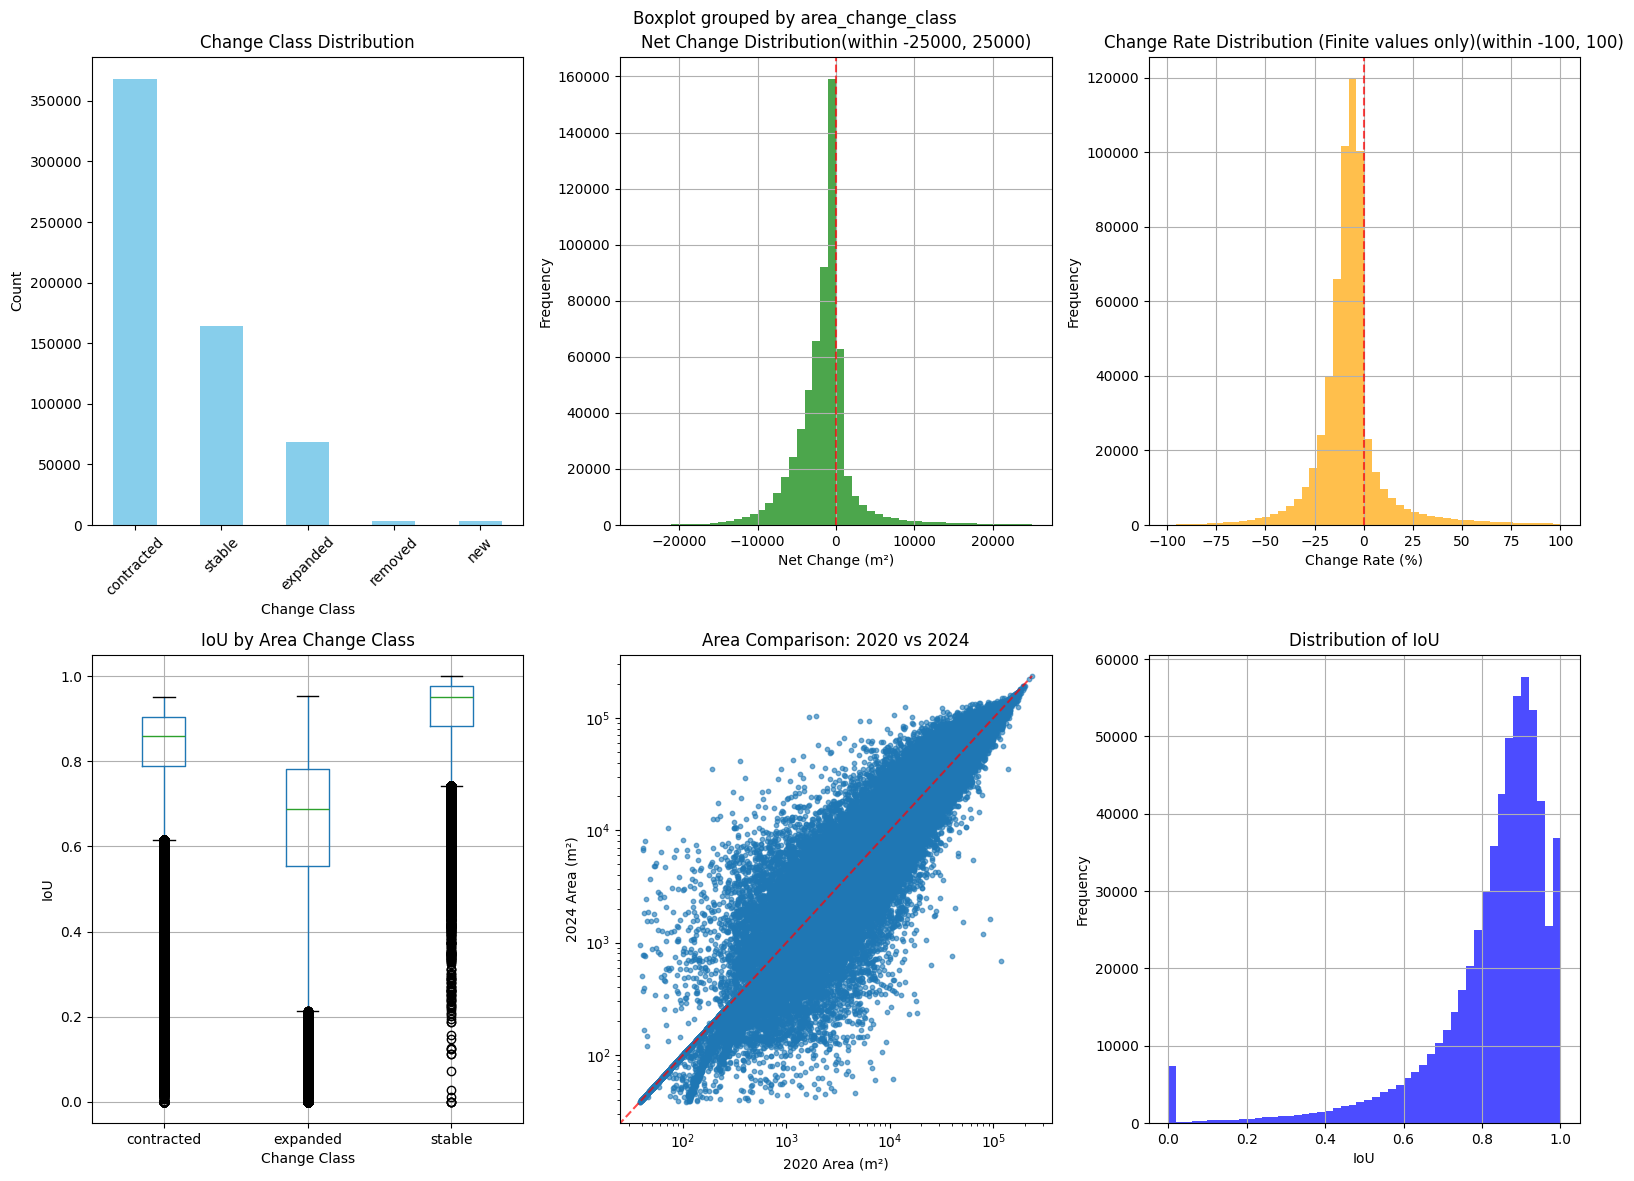


ANALYSIS COMPLETE


In [ ]:
results = analyze_hedgerow_changes(filtered_gdf)

In [ ]:
quick_hedgerow_summary(filtered_gdf)

QUICK SUMMARY:
Total records: 607,256
Stable: 164,000 (27.0%)
Expanded: 68,195 (11.2%)
Contracted: 368,116 (60.6%)
New: 3,253 (0.5%)
Removed: 3,692 (0.6%)
Net change: -888,940,912.18 m²


In [ ]:
filtered_gdf.to_csv(f"../csvs/patches_hedgerows_with_iou.csv")
filtered_gdf

,geometry,hedgerows_2024,hedgerows_2020,area_2020,area_2024,net_change,change_rate,area_change_class,intersection,union,iou
872,"POLYGON ((-5.11665 48.45542, -5.10515 48.45542...",LINESTRING (-5.116647565200277 48.460143431194...,None,0.000000,477.238671,477.238671,100.000000,new,0.000000,477.238671,0.000000
3322,"POLYGON ((-5.09365 48.45542, -5.08215 48.45542...",MULTILINESTRING ((-5.091588113664823 48.455592...,MULTILINESTRING ((-5.087781654415173 48.460865...,1802.690021,1802.690021,0.000000,0.000000,stable,1802.690021,1802.690021,1.000000
4547,"POLYGON ((-5.08215 48.45542, -5.07065 48.45542...",MULTILINESTRING ((-5.080937730652012 48.458186...,MULTILINESTRING ((-5.080747172179662 48.457216...,3541.709409,3541.709409,0.000000,0.000000,stable,3541.709409,3541.709409,1.000000
35159,"POLYGON ((-4.79469 48.35619, -4.78319 48.35619...",None,LINESTRING (-4.785683178240963 48.362467223218...,1150.152657,0.000000,-1150.152657,-100.000000,removed,0.000000,1150.152657,0.000000
35160,"POLYGON ((-4.79469 48.36383, -4.78319 48.36383...",LINESTRING (-4.783250890699998 48.365695960042...,LINESTRING (-4.783348856521463 48.365679559741...,163.500980,84.791088,-78.709893,-48.140318,contracted,84.680599,163.611469,0.517571
...,...,...,...,...,...,...,...,...,...,...,...
1561982,"POLYGON ((9.54386 42.28494, 9.55536 42.28494, ...",MULTILINESTRING ((9.545569357113168 42.2904447...,MULTILINESTRING ((9.543857871630312 42.2877315...,20543.782932,27216.582018,6672.799085,32.480868,expanded,17557.677119,30202.687462,0.581328
1561983,"POLYGON ((9.54386 42.29345, 9.55536 42.29345, ...",MULTILINESTRING ((9.544712404420144 42.3011536...,MULTILINESTRING ((9.545168124204048 42.3009596...,28626.808770,34274.851498,5648.042728,19.729907,expanded,25453.712639,37447.947629,0.679709
1561984,"POLYGON ((9.54386 42.30195, 9.55536 42.30195, ...",MULTILINESTRING ((9.544418522083697 42.3104550...,MULTILINESTRING ((9.544137404586712 42.3022902...,2764.264952,6035.864916,3271.599964,118.353342,expanded,2508.828978,6291.300890,0.398777
1561985,"POLYGON ((9.54386 42.31046, 9.55536 42.31046, ...",MULTILINESTRING ((9.54401678352858 42.31706359...,MULTILINESTRING ((9.54401678352858 42.31706359...,6162.813477,8485.501046,2322.687569,37.688753,expanded,6162.813477,8485.501046,0.726276
